In [1]:
# %% [markdown]
# # Tutorial 2: Architectural Discovery with Block-Based Search
# 
# In the previous tutorial, we fine-tuned a known architecture (MLP). But what if the best architecture for our problem is a novel combination of different layer types?
# 
# In this notebook, we'll unleash SNAC-pack to **discover new architectures** by combining building blocks like **Convolutional layers**, **Attention**, and **MLPs**.
# 
# ## The New Challenge
# 
# Since we are building arbitrary structures, our hardware estimator may not be accurate. We will instead optimize for two hardware-agnostic objectives:
# 1.  **Accuracy** (Maximize ⬆️)
# 2.  **Computational Cost (BOPs)** (Minimize ⬇️)

# %%
# Basic imports and setup
import os
import yaml
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import SNAC-pack utilities
from utils.tf_global_search5 import GlobalSearchTF
from utils.tf_visualization import plot_pareto_fronts
from utils.tf_local_search1 import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist

# Plotting settings and TF logging
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print("TensorFlow Version:", tf.__version__)

# --- Configuration ---
N_TRIALS_HYBRID = 5 # Note: Increase for a real search
EPOCHS_HYBRID = 15
SUBSET_SIZE_HYBRID = 30000
RESULTS_DIR_HYBRID = "./results/tutorial2_Hybrid_Discovery"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

2025-08-30 10:04:02.592857: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow Version: 2.15.0


In [2]:
# %% [markdown]
# ## Global Search: Building with Blocks
# 
# We first define a `search_space` in a YAML file. This file provides SNAC-pack with the "Lego bricks" it can use to build and test new architectures. [cite_start]We'll allow it to choose between `Conv`, `MLP`, and `ConvAttn` blocks[cite: 73].

# %%
# --- Create the YAML configuration file for the hybrid search ---
search_space_yaml = """
channel_space: [8, 16, 32]
mlp_width_space: [32, 64, 128]
kernel_space: [1, 3, 5]
act_space: ["ReLU", "GELU"]
norm_space: [null, "batch"]
block_types: ["Conv", "MLP", "ConvAttn", "None"]
conv_attn: 
  hidden_channel_space: [4, 8, 16]
num_blocks: 3
initial_img_size: 11
output_dim: 10
"""
with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")

# --- Objectives for Hybrid Search (Performance vs. Cost) ---
OBJECTIVE_NAMES_HYBRID = ['performance_metric', 'bops']
MAXIMIZE_FLAGS_HYBRID = [True, False]

# --- Run the Hybrid Search ---
print("\n" + "="*50)
print("Running Part 2: Hybrid Architecture Global Search...")
print("This will take several minutes...")
print("="*50)

searcher_hybrid = GlobalSearchTF(search_space_path=SEARCH_SPACE_PATH, results_dir=RESULTS_DIR_HYBRID)

study_hybrid = searcher_hybrid.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_hybrid.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID
)

print("\nGlobal Search Complete!")

Created search space configuration file: hybrid_search_space.yaml

Running Part 2: Hybrid Architecture Global Search...
This will take several minutes...

Starting BLOCK Global Search on MNIST



[I 2025-08-30 10:04:06,041] A new study created in memory with name: no-name-eab04e7d-dfc5-469b-b779-486ab4eeb3ec


Data loaded and preprocessed:
  Resize: 11x11
  x_train shape: (30000, 11, 11, 1), x_val shape: (10000, 11, 11, 1)
  y_train shape: (30000,), y_val shape: (10000,)


[I 2025-08-30 10:04:21,375] Trial 0 finished with values: [0.8981000185012817, 165617664.0] and parameters: {'b0': 'Conv', 'b1': 'MLP', 'b2': 'Conv', 'b0_Conv_channels_0': 0, 'b0_Conv_channels_1': 2, 'b0_Conv_kernels_0': 1, 'b0_Conv_kernels_1': 5, 'b0_Conv_acts_0': 'ReLU', 'b0_Conv_acts_1': 'ReLU', 'b0_Conv_norms_0': 'batch', 'b0_Conv_norms_1': None, 'b1_MLP_units': 1, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 0: Accuracy=0.8981, BOPs=165617664


...

Trial 2: Accuracy=0.6331, BOPs=6389760


[I 2025-08-30 10:04:59,858] Trial 3 finished with values: [0.573199987411499, 58335232.0] and parameters: {'b0': 'None', 'b1': 'Conv', 'b2': 'ConvAttn', 'b1_Conv_channels_0': 0, 'b1_Conv_channels_1': 1, 'b1_Conv_kernels_0': 5, 'b1_Conv_kernels_1': 3, 'b1_Conv_acts_0': 'GELU', 'b1_Conv_acts_1': 'ReLU', 'b1_Conv_norms_0': None, 'b1_Conv_norms_1': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 3: Accuracy=0.5732, BOPs=58335232


[I 2025-08-30 10:05:06,576] Trial 4 finished with values: [0.8845000267028809, 29097984.0] and parameters: {'b0': 'None', 'b1': 'MLP', 'b2': 'None', 'b1_MLP_units': 2, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 4: Accuracy=0.8845, BOPs=29097984

CSV results saved to ./results/tutorial2_Hybrid_Discovery/block_search_results.csv

🏆 Best model architecture (Trial 0) saved for local search:
   - Source: ./results/tutorial2_Hybrid_Discovery/trial_0_arch.yaml
   - Destination: ./results/tutorial2_Hybrid_Discovery/best_model_for_local_search.yaml
   - Accuracy: 0.8981

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'performance_metric': 0.8981000185012817, 'bops': 165617664.0}
  Params: {'b0': 'Conv', 'b1': 'MLP', 'b2': 'Conv', 'b0_Conv_channels_0': 0, 'b0_Conv_channels_1': 2, 'b0_Conv_kernels_0': 1, 'b0_Conv_kernels_1': 5, 'b0_Conv_acts_0': 'ReLU', 'b0_Conv_acts_1': 'ReLU', 'b0_Conv_norms_0': 'batch', 'b0_Conv_norms_1': None, 'b1_MLP_units': 1, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_

--- Best Discovered Architecture (by Accuracy) ---
Trial Number: 0
Accuracy: 0.8981
BOPs: 1.66e+08

Architecture components:
- Type: Conv, Name: conv_block_0
- Type: Flatten, Name: initial_flatten
- Type: MLP, Name: mlp_block_1
- Type: MLP, Name: classifier_head

--- Generating Pareto Front Plot for Hybrid Search ---
2D Pareto fronts plot saved to ./results/tutorial2_Hybrid_Discovery/pareto_fronts_2d.png


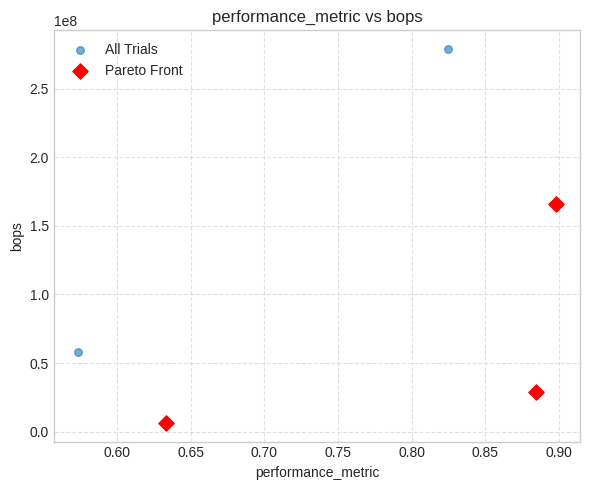

In [3]:
# %% [markdown]
# ## Analyzing the Global Search Results
# 
# The search has finished exploring different architectural combinations. Let's see what it found!

# %%
results_df_hybrid = pd.DataFrame(searcher_hybrid.results)

if not results_df_hybrid.empty:
    # --- Inspect the Best Discovered Architecture ---
    print("--- Best Discovered Architecture (by Accuracy) ---")
    best_trial_row = results_df_hybrid.loc[results_df_hybrid['performance_metric'].idxmax()]
    print(f"Trial Number: {best_trial_row['trial']}")
    print(f"Accuracy: {best_trial_row['performance_metric']:.4f}")
    print(f"BOPs: {best_trial_row['bops']:.2e}")
    
    # Load and print the architecture from its YAML file
    with open(best_trial_row['yaml_path'], 'r') as f:
        best_arch_yaml = yaml.safe_load(f)
        
    print("\nArchitecture components:")
    for component in best_arch_yaml['architecture']['components']:
        print(f"- Type: {component['block_type']}, Name: {component['name']}")

    # --- Visualize the Pareto Front (Accuracy vs BOPs) ---
    print("\n--- Generating Pareto Front Plot for Hybrid Search ---")
    plot_pareto_fronts(results_df_hybrid, list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID)), save_dir=searcher_hybrid.results_dir)
else:
    print("Hybrid search did not yield any results to analyze.")

In [4]:
# %% [markdown]
# ## Local Search: Compressing Our New Discovery
# 
# Just like before, the global search saved the best model. We will now apply the same powerful QAT and pruning techniques to this newly discovered hybrid model, demonstrating the consistent workflow of SNAC-pack.

# %%
# --- Configuration for Local Search ---
LOCAL_SEARCH_RESULTS_DIR = os.path.join(RESULTS_DIR_HYBRID, "local_search")
LOCAL_SEARCH_CONFIG_PATH = os.path.join(RESULTS_DIR_HYBRID, 'local_search_settings.yaml')

# Define settings for QAT and pruning
local_search_settings = {
    'precision_pairs': [
        {'total_bits': 8, 'int_bits': 3},
        {'total_bits': 4, 'int_bits': 1},
    ],
    'pruning_iterations': 3,
    'epochs_per_iteration': 8,
    'pruning_rate': 0.8,
}

# Write the settings to a YAML file
with open(LOCAL_SEARCH_CONFIG_PATH, 'w') as f:
    yaml.dump(local_search_settings, f)
print(f"Created local search configuration file: {LOCAL_SEARCH_CONFIG_PATH}")

# Path to the best model found by the global search
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_HYBRID, "best_model_for_local_search.yaml")

# --- Load Dataset for Local Search ---
resize_val = searcher_hybrid.search_space.get('initial_img_size', 11)
x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
    resize_val=resize_val, 
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False,
    one_hot=False
)

# --- Run the Local Search ---
if os.path.exists(ARCHITECTURE_YAML_PATH):
    local_search_df_hybrid = local_search_entrypoint(
        architecture_yaml_path=ARCHITECTURE_YAML_PATH,
        local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_SEARCH_RESULTS_DIR
    )
else:
    print(f"ERROR: Could not find the architecture file: {ARCHITECTURE_YAML_PATH}")
    local_search_df_hybrid = pd.DataFrame()

Created local search configuration file: ./results/tutorial2_Hybrid_Discovery/local_search_settings.yaml
Data loaded and preprocessed:
  Resize: 11x11
  x_train shape: (30000, 11, 11, 1), x_val shape: (10000, 11, 11, 1)
  y_train shape: (30000,), y_val shape: (10000,)

 STARTING LOCAL SEARCH STAGE 
--- Loading model architecture from: ./results/tutorial2_Hybrid_Discovery/best_model_for_local_search.yaml ---
--- Model successfully reconstructed ---
Model: "BlockArchitecture"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 11, 11, 1)]       0         
                                                                 
 conv_block_0 (Sequential)   (None, 7, 7, 32)          6480      
                                                                 
 initial_flatten (Flatten)   (None, 1568)              0         
                                                           

/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/8
235/235 [==============================] - 5s 7ms/step - loss: 2.2062 - accuracy: 0.5617 - val_loss: 6.1204 - val_accuracy: 0.1196
Epoch 2/8
235/235 [==============================] - 1s 5ms/step - loss: 1.1577 - accuracy: 0.7507 - val_loss: 1.0161 - val_accuracy: 0.7632
Epoch 3/8
235/235 [==============================] - 1s 5ms/step - loss: 1.0210 - accuracy: 0.7547 - val_loss: 8.1559 - val_accuracy: 0.1643
Epoch 4/8
235/235 [==============================] - 1s 5ms/step - loss: 1.0921 - accuracy: 0.7449 - val_loss: 1.7439 - val_accuracy: 0.6815
Epoch 5/8
235/235 [==============================] - 1s 5ms/step - loss: 0.9045 - accuracy: 0.7995 - val_loss: 0.9060 - val_accuracy: 0.7781
Epoch 6/8
235/235 [==============================] - 1s 5ms/step - loss: 0.7646 - accuracy: 0.8353 - val_loss: 0.9085 - val_accuracy: 0.8223
Epoch 7/8
235/235 [==============================] - 1s 5ms/step - loss: 0.7273 - accuracy: 0.8444 - val_loss: 0.9331 - val_accuracy: 0.8043
Epoch 8/8
235

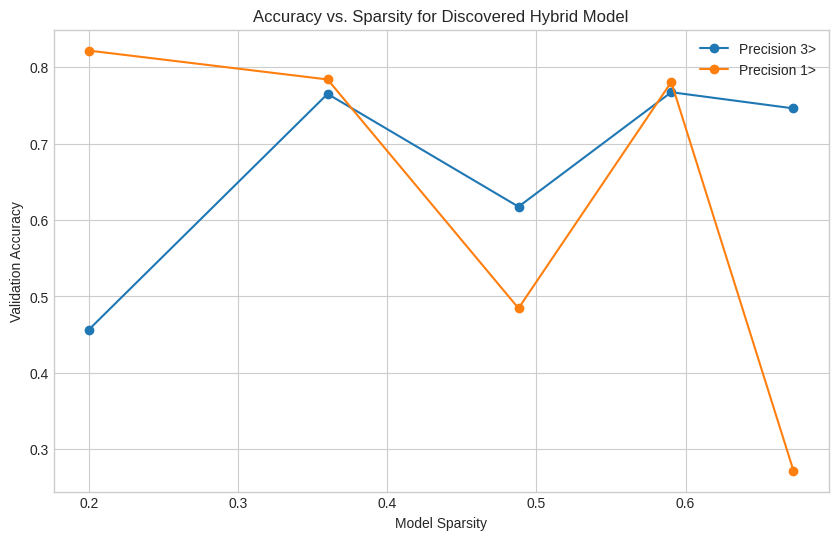

In [5]:
# %% [markdown]
# ## Analyzing the Local Search Results
# 
# Finally, let's visualize the accuracy/sparsity trade-off for our discovered and compressed model.

# %%
if 'local_search_df_hybrid' in locals() and not local_search_df_hybrid.empty:
    plt.figure(figsize=(10, 6))
    
    precisions = local_search_df_hybrid['Precision'].unique()
    
    for prec in precisions:
        subset = local_search_df_hybrid[local_search_df_hybrid['Precision'] == prec]
        plt.plot(subset['Sparsity'], subset['Accuracy'], marker='o', linestyle='-', label=f'Precision {prec}')
        
    plt.title('Accuracy vs. Sparsity for Discovered Hybrid Model')
    plt.xlabel('Model Sparsity')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Local search did not produce results to analyze.")